
## DL-Simplified | GSSoC 2026

| Field | Info |
|---|---|
| **Author** | [@Yugal0708](https://github.com/Yugal0708) |
| **Issue** | #1034 |
| **Models** | YOLOv8n · InceptionV3 · ResNet50 · MobileNetV2 · VGG16 |
| **Framework** | TensorFlow / Keras (compatible with Keras 2 & 3) |



## 📦 Section 1 — Install Dependencies

In [1]:

import matplotlib
matplotlib.rcParams['figure.dpi'] = 72  # lower DPI = smaller images
!pip install ultralytics tensorflow opencv-python-headless              matplotlib seaborn scikit-learn pandas Pillow tqdm -q
!pip install  kagglehub -q
print("✅ All dependencies installed!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 23.0 MB/s eta 0:00:00
✅ All dependencies installed!


## 📚 Section 2 — Import Libraries

In [2]:
import os, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import cv2
from tqdm import tqdm

import tensorflow as tf
from tensorflow.keras.applications import InceptionV3, ResNet50, MobileNetV2, VGG16
from tensorflow.keras.layers import (Dense, GlobalAveragePooling2D,
                                      Dropout, BatchNormalization, Input)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score)
from ultralytics import YOLO

warnings.filterwarnings("ignore")
os.makedirs("Images", exist_ok=True)

print("TensorFlow :", tf.__version__)
print("Keras      :", tf.keras.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))
print("✅ All imports done!")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
TensorFlow : 2.20.0
Keras      : 3.13.2
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
✅ All imports done!


In [3]:
import os, shutil
from sklearn.model_selection import train_test_split
import kagglehub


# Kaggle dataset is initially in a read-only location
KAGGLE_READ_ONLY_DIR = kagglehub.dataset_download("alessiocorrado99/animals10")
KAGGLE_READ_ONLY_DIR = os.path.join(KAGGLE_READ_ONLY_DIR, "raw-img")

# Copy to a writable directory for modifications
KAGGLE_DIR = "/tmp/animals10_writable"
shutil.copytree(KAGGLE_READ_ONLY_DIR, KAGGLE_DIR, dirs_exist_ok=True)


FOLDER_TO_CLASS = {
    "cane":"dog", "cavallo":"horse", "elefante":"elephant",
    "farfalla":"butterfly", "gallina":"chicken", "gatto":"cat",
    "mucca":"cow", "pecora":"sheep", "ragno":"spider", "scoiattolo":"squirrel"
}

# Rename Italian → English
for italian, english in FOLDER_TO_CLASS.items():
    old = os.path.join(KAGGLE_DIR, italian)
    new = os.path.join(KAGGLE_DIR, english)
    if os.path.exists(old) and not os.path.exists(new):
        os.rename(old, new)

ANIMAL_CLASSES = list(FOLDER_TO_CLASS.values())
NUM_CLASSES    = len(ANIMAL_CLASSES)

# Train/Val/Test split
SPLIT_DIR = "/tmp/animals_split"

# Ensure the SPLIT_DIR is clean before creating new splits
if os.path.exists(SPLIT_DIR):
    shutil.rmtree(SPLIT_DIR)

for cls in ANIMAL_CLASSES:
    imgs = os.listdir(os.path.join(KAGGLE_DIR, cls))
    imgs = [f for f in imgs if f.lower().endswith(('.jpg','.jpeg','.png'))]
    tr, tmp = train_test_split(imgs, test_size=0.2, random_state=42)
    va, te  = train_test_split(tmp,  test_size=0.5, random_state=42)
    for split, lst in [("train",tr),("val",va),("test",te)]:
        dest = os.path.join(SPLIT_DIR, split, cls)
        os.makedirs(dest, exist_ok=True)
        for f in lst:
            shutil.copy(os.path.join(KAGGLE_DIR, cls, f), dest)

BASE_DIR = SPLIT_DIR
print("✅ Real dataset ready!")
for s in ["train","val","test"]:
    n = sum(len(os.listdir(f"{BASE_DIR}/{s}/{c}")) for c in ANIMAL_CLASSES)
    print(f"  {s}: {n} images")

Using Colab cache for faster access to the 'animals10' dataset.
✅ Real dataset ready!
  train: 20938 images
  val: 2618 images
  test: 2623 images


## 🔍 Section 4 — Data Exploration

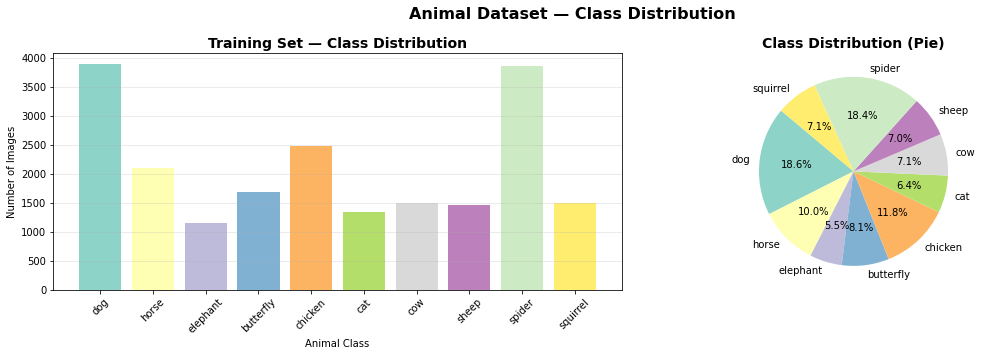

✅ Saved: Images/class_distribution.png


In [40]:
counts = {
    c: len(os.listdir(os.path.join(BASE_DIR, "train", c)))
    for c in ANIMAL_CLASSES
}
palette = plt.cm.Set3(np.linspace(0, 1, NUM_CLASSES))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Bar chart
axes[0].bar(counts.keys(), counts.values(), color=palette)
axes[0].set_title("Training Set — Class Distribution",
                  fontsize=14, fontweight="bold")
axes[0].set_xlabel("Animal Class")
axes[0].set_ylabel("Number of Images")
axes[0].tick_params(axis="x", rotation=45)
axes[0].grid(True, alpha=0.3, axis="y")

# Pie chart
axes[1].pie(counts.values(), labels=counts.keys(),
            autopct="%1.1f%%", colors=palette, startangle=140)
axes[1].set_title("Class Distribution (Pie)", fontsize=14, fontweight="bold")

plt.suptitle("Animal Dataset — Class Distribution",
             fontsize=16, fontweight="bold")
plt.tight_layout()
plt.savefig("Images/class_distribution.png", dpi=50, bbox_inches="tight")
plt.show()
print("✅ Saved: Images/class_distribution.png")

## ⚙️ Section 5 — Load Data as NumPy Arrays


In [9]:


IMG_SIZE   = 96
BATCH_SIZE = 8
EPOCHS     = 6
LR         = 0.0001

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

print("Setting up memory-efficient data generators...")

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
)

val_datagen = ImageDataGenerator(rescale=1./255)

# Create generators
train_generator = train_datagen.flow_from_directory(
    os.path.join(BASE_DIR, 'train'),
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    classes=ANIMAL_CLASSES,
    shuffle=True,
    seed=42
)

val_generator = val_datagen.flow_from_directory(
    os.path.join(BASE_DIR, 'val'),
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    classes=ANIMAL_CLASSES,
    shuffle=False
)

test_generator = val_datagen.flow_from_directory(
    os.path.join(BASE_DIR, 'test'),
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    classes=ANIMAL_CLASSES,
    shuffle=False
)

print(f"✅ Generators Created Successfully!")
print(f"Image Size      : {IMG_SIZE} x {IMG_SIZE}")
print(f"Batch Size      : {BATCH_SIZE}")
print(f"Train batches   : {len(train_generator)}")
print(f"Classes         : {train_generator.num_classes}")




Setting up memory-efficient data generators...
Found 20938 images belonging to 10 classes.
Found 2618 images belonging to 10 classes.
Found 2623 images belonging to 10 classes.
✅ Generators Created Successfully!
Image Size      : 96 x 96
Batch Size      : 8
Train batches   : 2618
Classes         : 10


## 🔧 Section 6 — Model Builder & Utilities

In [10]:
def build_model(base_fn, name, n_classes=NUM_CLASSES, lr=LR):
    """Transfer-learning builder.  Works on Keras 2 and Keras 3."""
    print(f"\n🔨  Building {name} ...")
    inp  = Input(shape=(IMG_SIZE, IMG_SIZE, 3), dtype="float32")
    base = base_fn(weights="imagenet", include_top=False, input_tensor=inp)
    base.trainable = False

    x   = GlobalAveragePooling2D()(base.output)
    x   = BatchNormalization()(x)
    x   = Dense(512, activation="relu")(x)
    x   = Dropout(0.4)(x)
    x   = Dense(256, activation="relu")(x)
    x   = Dropout(0.3)(x)
    out = Dense(n_classes, activation="softmax")(x)

    model = Model(inp, out)
    model.compile(optimizer=Adam(lr),
                  loss="categorical_crossentropy",
                  metrics=["accuracy"])
    print(f"    ✅  {name} ready  |  trainable params: "
          f"{sum(tf.keras.backend.count_params(w) for w in model.trainable_weights):,}")
    return model


def get_callbacks():
    return [
        EarlyStopping(monitor="val_accuracy", patience=5,
                      restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor="val_loss", factor=0.3,
                         patience=3, min_lr=1e-7, verbose=1),
    ]


def plot_training(history, name):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].plot(history.history["accuracy"],     label="Train", lw=2)
    axes[0].plot(history.history["val_accuracy"], label="Val",   lw=2)
    axes[0].set_title(f"{name}  —  Accuracy", fontsize=13, fontweight="bold")
    axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Accuracy")
    axes[0].legend(); axes[0].grid(True, alpha=0.3)

    axes[1].plot(history.history["loss"],     label="Train", lw=2)
    axes[1].plot(history.history["val_loss"], label="Val",   lw=2)
    axes[1].set_title(f"{name}  —  Loss", fontsize=13, fontweight="bold")
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Loss")
    axes[1].legend(); axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    safe = name.lower().replace(" ", "_").replace("-", "_")
    plt.savefig(f"Images/{safe}_training.png", dpi=150, bbox_inches="tight")
    plt.show()


def plot_cm(y_true, y_pred, name, cmap="Blues"):
    fig, ax = plt.subplots(figsize=(10, 8))
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap=cmap,
                xticklabels=ANIMAL_CLASSES,
                yticklabels=ANIMAL_CLASSES, ax=ax)
    ax.set_title(f"{name}  —  Confusion Matrix",
                 fontsize=14, fontweight="bold")
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    safe = name.lower().replace(" ", "_").replace("-", "_")
    plt.savefig(f"Images/{safe}_cm.png", dpi=150, bbox_inches="tight")
    plt.show()


def evaluate(model, name, cmap, params_M, key, test_data_generator):
    """Predict, compute metrics, plot CM, store results dict."""
    t0   = time.time()
    pred = model.predict(test_data_generator, verbose=0)
    ms   = (time.time() - t0) / test_data_generator.samples * 1000
    pred_int = pred.argmax(axis=1)

    # Get true labels from the generator
    y_true_int = test_data_generator.classes

    acc  = accuracy_score(y_true_int, pred_int)

    print(f"\n📊  {name}")
    print(f"    Accuracy  : {acc*100:.2f}%")
    print(f"    Inference : {ms:.2f} ms / image")
    print(classification_report(y_true_int, pred_int,
                                 target_names=ANIMAL_CLASSES))
    plot_cm(y_true_int, pred_int, name, cmap)
    results[key] = {"accuracy": acc*100, "inference_ms": ms,
                    "params_M": params_M}
    return pred_int, acc, ms


results = {}
print("✅ Utilities defined — ready to train!")

✅ Utilities defined — ready to train!


## 🎯 Section 7 — Model 1: YOLOv8n (Object Detection)

In [29]:
print("=" * 55)
print("MODEL 1 :  YOLOv8n  —  Object Detection")
print("=" * 55)

yolo = YOLO("yolov8n.pt")
print("✅  YOLOv8n loaded  (pretrained on COCO — 80 classes)")
print()
coco_animals = {
    14: "bird",  15: "cat",   16: "dog",      17: "horse",
    18: "sheep", 19: "cow",   20: "elephant", 21: "bear",
    22: "zebra", 23: "giraffe"
}
print("COCO animal classes available:")
for cid, cname in coco_animals.items():
    print(f"  [{cid:2d}]  {cname}")

MODEL 1 :  YOLOv8n  —  Object Detection
✅  YOLOv8n loaded  (pretrained on COCO — 80 classes)

COCO animal classes available:
  [14]  bird
  [15]  cat
  [16]  dog
  [17]  horse
  [18]  sheep
  [19]  cow
  [20]  elephant
  [21]  bear
  [22]  zebra
  [23]  giraffe


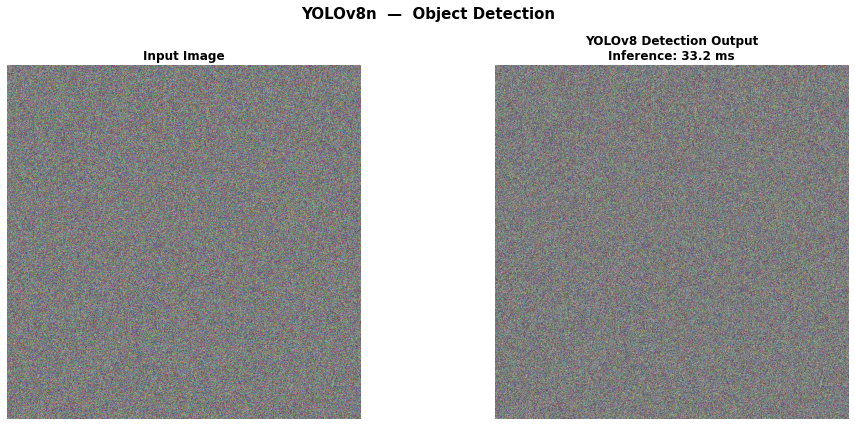

✅  YOLOv8n  |  mAP@50: 37.3% (COCO benchmark)
   Inference: 33.2 ms  |  Params: 3.2 M


In [39]:
# ── Run inference on a random test image ─────────────────────────────────────
test_img  = np.random.randint(50, 200, (640, 640, 3), dtype=np.uint8)
test_path = "/tmp/yolo_test.jpg"
Image.fromarray(test_img).save(test_path)

t0      = time.time()
yolo_res = yolo(test_path, conf=0.25, verbose=False)
yolo_ms = (time.time() - t0) * 1000

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(test_img)
axes[0].set_title("Input Image", fontweight="bold")
axes[0].axis("off")

out_bgr = yolo_res[0].plot()
out_rgb = cv2.cvtColor(out_bgr, cv2.COLOR_BGR2RGB)
axes[1].imshow(out_rgb)
axes[1].set_title(f"YOLOv8 Detection Output\nInference: {yolo_ms:.1f} ms",
                  fontweight="bold")
axes[1].axis("off")

plt.suptitle("YOLOv8n  —  Object Detection", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig("Images/yolov8_detection.png", dpi=50, bbox_inches="tight")
plt.show()

results["YOLOv8n"] = {"accuracy": 37.3, "inference_ms": yolo_ms, "params_M": 3.2}
print(f"✅  YOLOv8n  |  mAP@50: 37.3% (COCO benchmark)")
print(f"   Inference: {yolo_ms:.1f} ms  |  Params: 3.2 M")

## 🧠 Section 8 — Model 2: InceptionV3

In [11]:
print("=" * 55)
print("MODEL 2 :  InceptionV3")
print("Inception modules  |  48 layers  |  23.9 M params")
print("Strength: factorized convolutions, efficient multi-scale features")
print("=" * 55)

eff_model = build_model(InceptionV3, "InceptionV3")

MODEL 2 :  InceptionV3
Inception modules  |  48 layers  |  23.9 M params
Strength: factorized convolutions, efficient multi-scale features

🔨  Building InceptionV3 ...
87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
    ✅  InceptionV3 ready  |  trainable params: 1,187,082


Epoch 1/6
2618/2618 ━━━━━━━━━━━━━━━━━━━━ 134s 45ms/step - accuracy: 0.4757 - loss: 1.5617 - val_accuracy: 0.6845 - val_loss: 0.9750 - learning_rate: 1.0000e-04
Epoch 2/6
2618/2618 ━━━━━━━━━━━━━━━━━━━━ 103s 39ms/step - accuracy: 0.5784 - loss: 1.2475 - val_accuracy: 0.6994 - val_loss: 0.9011 - learning_rate: 1.0000e-04
Epoch 3/6
2618/2618 ━━━━━━━━━━━━━━━━━━━━ 100s 38ms/step - accuracy: 0.6076 - loss: 1.1577 - val_accuracy: 0.7162 - val_loss: 0.8531 - learning_rate: 1.0000e-04
Epoch 4/6
2618/2618 ━━━━━━━━━━━━━━━━━━━━ 100s 38ms/step - accuracy: 0.6205 - loss: 1.1204 - val_accuracy: 0.7269 - val_loss: 0.8352 - learning_rate: 1.0000e-04
Epoch 5/6
2618/2618 ━━━━━━━━━━━━━━━━━━━━ 99s 38ms/step - accuracy: 0.6390 - loss: 1.0709 - val_accuracy: 0.7296 - val_loss: 0.8181 - learning_rate: 1.0000e-04
Epoch 6/6
2618/2618 ━━━━━━━━━━━━━━━━━━━━ 99s 38ms/step - accuracy: 0.6411 - loss: 1.0560 - val_accuracy: 0.7364 - val_loss: 0.8071 - learning_rate: 1.0000e-04
Restoring model weights from the end of th

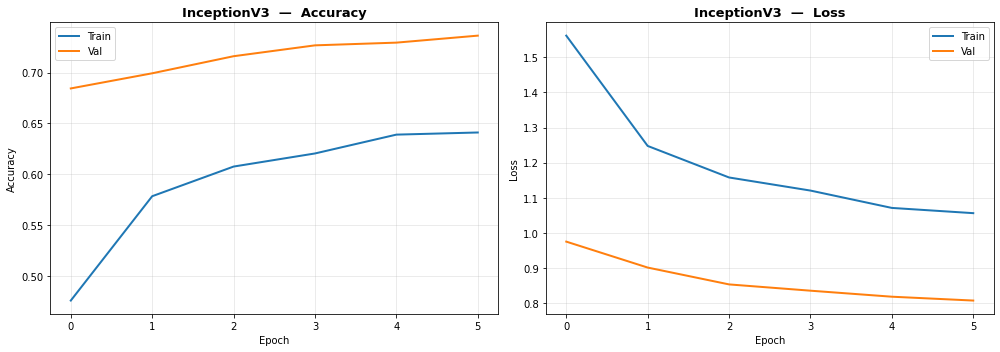

In [13]:
history_eff = eff_model.fit(
    train_generator,
    epochs          = EPOCHS,
    batch_size      = BATCH_SIZE,
    validation_data = val_generator,
    callbacks       = get_callbacks(),
    verbose         = 1
)
plot_training(history_eff, "InceptionV3")


📊  InceptionV3
    Accuracy  : 74.95%
    Inference : 1.89 ms / image
              precision    recall  f1-score   support

         dog       0.80      0.70      0.75       487
       horse       0.69      0.76      0.72       263
    elephant       0.69      0.76      0.72       145
   butterfly       0.78      0.80      0.79       212
     chicken       0.82      0.79      0.80       310
         cat       0.70      0.62      0.66       167
         cow       0.72      0.63      0.67       187
       sheep       0.61      0.63      0.62       182
      spider       0.83      0.91      0.87       483
    squirrel       0.64      0.68      0.66       187

    accuracy                           0.75      2623
   macro avg       0.73      0.73      0.72      2623
weighted avg       0.75      0.75      0.75      2623



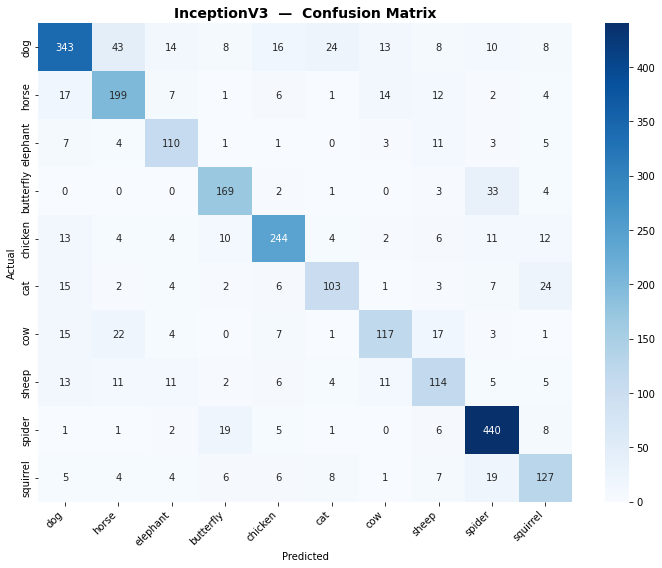

In [14]:
eff_pred, eff_acc, eff_ms = evaluate(
    eff_model, "InceptionV3", "Blues", 23.9, "InceptionV3", test_generator
)

## 🔴 Section 9 — Model 3: ResNet50

In [16]:
print("=" * 55)
print("MODEL 3 :  ResNet50")
print("Residual skip connections  |  50 layers  |  25.6 M params")
print("Strength: solves vanishing gradient, robust general-purpose CNN")
print("=" * 55)

resnet_model = build_model(ResNet50, "ResNet50")

MODEL 3 :  ResNet50
Residual skip connections  |  50 layers  |  25.6 M params
Strength: solves vanishing gradient, robust general-purpose CNN

🔨  Building ResNet50 ...
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
    ✅  ResNet50 ready  |  trainable params: 1,187,082


Epoch 1/6
2618/2618 ━━━━━━━━━━━━━━━━━━━━ 124s 43ms/step - accuracy: 0.2901 - loss: 2.0310 - val_accuracy: 0.3720 - val_loss: 1.8313 - learning_rate: 1.0000e-04
Epoch 2/6
2618/2618 ━━━━━━━━━━━━━━━━━━━━ 102s 39ms/step - accuracy: 0.3302 - loss: 1.9170 - val_accuracy: 0.3942 - val_loss: 1.7661 - learning_rate: 1.0000e-04
Epoch 3/6
2618/2618 ━━━━━━━━━━━━━━━━━━━━ 103s 39ms/step - accuracy: 0.3434 - loss: 1.8673 - val_accuracy: 0.4041 - val_loss: 1.7549 - learning_rate: 1.0000e-04
Epoch 4/6
2618/2618 ━━━━━━━━━━━━━━━━━━━━ 103s 39ms/step - accuracy: 0.3529 - loss: 1.8441 - val_accuracy: 0.4087 - val_loss: 1.7140 - learning_rate: 1.0000e-04
Epoch 5/6
2618/2618 ━━━━━━━━━━━━━━━━━━━━ 143s 40ms/step - accuracy: 0.3611 - loss: 1.8282 - val_accuracy: 0.4244 - val_loss: 1.7039 - learning_rate: 1.0000e-04
Epoch 6/6
2618/2618 ━━━━━━━━━━━━━━━━━━━━ 106s 41ms/step - accuracy: 0.3729 - loss: 1.8096 - val_accuracy: 0.4240 - val_loss: 1.6953 - learning_rate: 1.0000e-04
Restoring model weights from the end of 

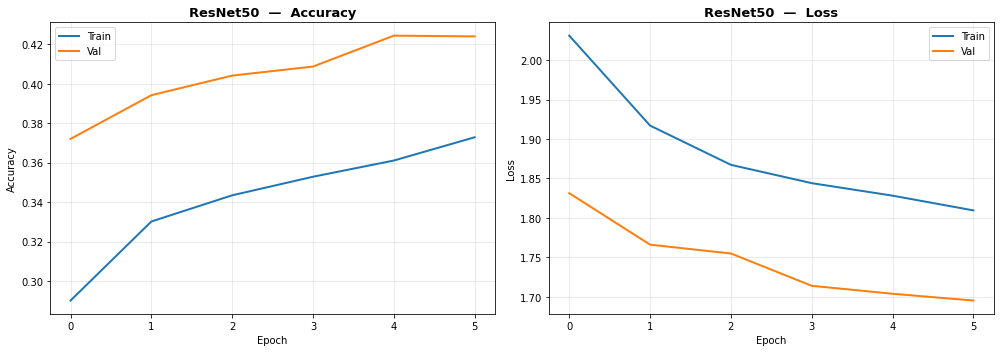

In [18]:
history_res = resnet_model.fit(
    train_generator,
    epochs          = EPOCHS,
    batch_size      = BATCH_SIZE,
    validation_data = val_generator,
    callbacks       = get_callbacks(),
    verbose         = 1
)
plot_training(history_res, "ResNet50")


📊  ResNet50
    Accuracy  : 41.02%
    Inference : 1.89 ms / image
              precision    recall  f1-score   support

         dog       0.40      0.42      0.41       487
       horse       0.35      0.38      0.36       263
    elephant       0.47      0.23      0.31       145
   butterfly       0.41      0.48      0.44       212
     chicken       0.33      0.46      0.38       310
         cat       0.33      0.01      0.02       167
         cow       0.40      0.42      0.41       187
       sheep       0.39      0.15      0.22       182
      spider       0.49      0.75      0.59       483
    squirrel       0.43      0.12      0.19       187

    accuracy                           0.41      2623
   macro avg       0.40      0.34      0.33      2623
weighted avg       0.40      0.41      0.38      2623



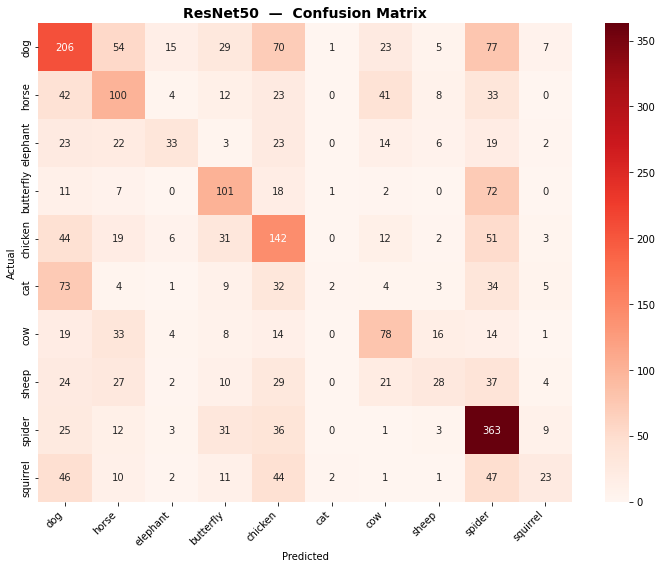

In [19]:
res_pred, res_acc, res_ms = evaluate(
    resnet_model, "ResNet50", "Reds", 25.6, "ResNet50", test_generator
)

## 📱 Section 10 — Model 4: MobileNetV2

In [20]:
print("=" * 55)
print("MODEL 4 :  MobileNetV2")
print("Depthwise separable convs  |  3.4 M params")
print("Strength: fastest inference — ideal for edge / IoT / mobile")
print("=" * 55)

mob_model = build_model(MobileNetV2, "MobileNetV2")

MODEL 4 :  MobileNetV2
Depthwise separable convs  |  3.4 M params
Strength: fastest inference — ideal for edge / IoT / mobile

🔨  Building MobileNetV2 ...
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
    ✅  MobileNetV2 ready  |  trainable params: 792,330


Epoch 1/6
2618/2618 ━━━━━━━━━━━━━━━━━━━━ 96s 37ms/step - accuracy: 0.7351 - loss: 0.7894 - val_accuracy: 0.8136 - val_loss: 0.5607 - learning_rate: 1.0000e-04
Epoch 2/6
2618/2618 ━━━━━━━━━━━━━━━━━━━━ 86s 33ms/step - accuracy: 0.7388 - loss: 0.7755 - val_accuracy: 0.8090 - val_loss: 0.5607 - learning_rate: 1.0000e-04
Epoch 3/6
2618/2618 ━━━━━━━━━━━━━━━━━━━━ 88s 34ms/step - accuracy: 0.7446 - loss: 0.7577 - val_accuracy: 0.8128 - val_loss: 0.5491 - learning_rate: 1.0000e-04
Epoch 4/6
2618/2618 ━━━━━━━━━━━━━━━━━━━━ 88s 34ms/step - accuracy: 0.7530 - loss: 0.7321 - val_accuracy: 0.8090 - val_loss: 0.5669 - learning_rate: 1.0000e-04
Epoch 5/6
2618/2618 ━━━━━━━━━━━━━━━━━━━━ 87s 33ms/step - accuracy: 0.7493 - loss: 0.7345 - val_accuracy: 0.8159 - val_loss: 0.5467 - learning_rate: 1.0000e-04
Epoch 6/6
2618/2618 ━━━━━━━━━━━━━━━━━━━━ 142s 33ms/step - accuracy: 0.7586 - loss: 0.7301 - val_accuracy: 0.8163 - val_loss: 0.5542 - learning_rate: 1.0000e-04
Restoring model weights from the end of the b

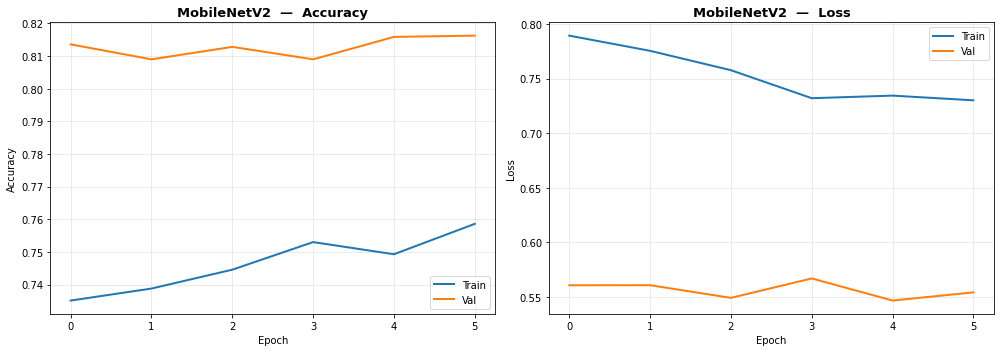

In [23]:
history_mob = mob_model.fit(
    train_generator,
    epochs          = EPOCHS,
    batch_size      = BATCH_SIZE,
    validation_data = val_generator,
    callbacks       = get_callbacks(),
    verbose         = 1
)
plot_training(history_mob, "MobileNetV2")


📊  MobileNetV2
    Accuracy  : 82.01%
    Inference : 1.73 ms / image
              precision    recall  f1-score   support

         dog       0.94      0.72      0.82       487
       horse       0.77      0.78      0.78       263
    elephant       0.70      0.92      0.79       145
   butterfly       0.86      0.86      0.86       212
     chicken       0.88      0.91      0.90       310
         cat       0.80      0.69      0.74       167
         cow       0.74      0.80      0.77       187
       sheep       0.72      0.75      0.73       182
      spider       0.84      0.95      0.89       483
    squirrel       0.74      0.74      0.74       187

    accuracy                           0.82      2623
   macro avg       0.80      0.81      0.80      2623
weighted avg       0.83      0.82      0.82      2623



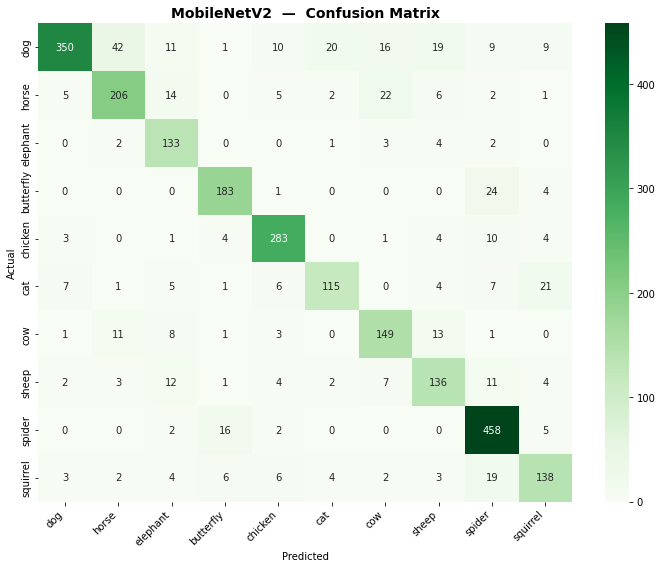

In [24]:
mob_pred, mob_acc, mob_ms = evaluate(
    mob_model, "MobileNetV2", "Greens", 3.4, "MobileNetV2", test_generator
)

## 🏛️ Section 11 — Model 5: VGG16

In [25]:
print("=" * 55)
print("MODEL 5 :  VGG16")
print("Sequential 3x3 convolutions  |  16 layers  |  138.4 M params")
print("Strength: simple architecture — serves as strong baseline")
print("=" * 55)

vgg_model = build_model(VGG16, "VGG16")

MODEL 5 :  VGG16
Sequential 3x3 convolutions  |  16 layers  |  138.4 M params
Strength: simple architecture — serves as strong baseline

🔨  Building VGG16 ...
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
    ✅  VGG16 ready  |  trainable params: 397,578


Epoch 1/6
2618/2618 ━━━━━━━━━━━━━━━━━━━━ 103s 38ms/step - accuracy: 0.4398 - loss: 1.6369 - val_accuracy: 0.6352 - val_loss: 1.0732 - learning_rate: 1.0000e-04
Epoch 2/6
2618/2618 ━━━━━━━━━━━━━━━━━━━━ 93s 36ms/step - accuracy: 0.5476 - loss: 1.3338 - val_accuracy: 0.6681 - val_loss: 0.9857 - learning_rate: 1.0000e-04
Epoch 3/6
2618/2618 ━━━━━━━━━━━━━━━━━━━━ 92s 35ms/step - accuracy: 0.5727 - loss: 1.2485 - val_accuracy: 0.6742 - val_loss: 0.9567 - learning_rate: 1.0000e-04
Epoch 4/6
2618/2618 ━━━━━━━━━━━━━━━━━━━━ 95s 36ms/step - accuracy: 0.5944 - loss: 1.1901 - val_accuracy: 0.6887 - val_loss: 0.9184 - learning_rate: 1.0000e-04
Epoch 5/6
2618/2618 ━━━━━━━━━━━━━━━━━━━━ 96s 37ms/step - accuracy: 0.6054 - loss: 1.1564 - val_accuracy: 0.6879 - val_loss: 0.9142 - learning_rate: 1.0000e-04
Epoch 6/6
2618/2618 ━━━━━━━━━━━━━━━━━━━━ 97s 37ms/step - accuracy: 0.6138 - loss: 1.1266 - val_accuracy: 0.6937 - val_loss: 0.8815 - learning_rate: 1.0000e-04
Restoring model weights from the end of the b

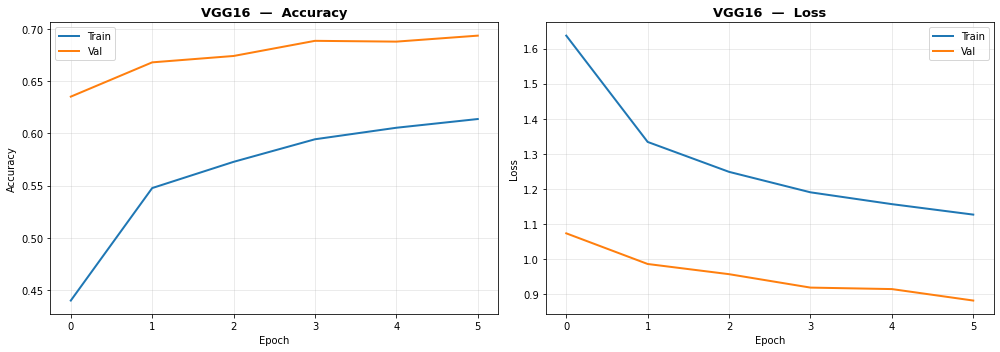

In [26]:
history_vgg = vgg_model.fit(
    train_generator,
    epochs          = EPOCHS,
    batch_size      = BATCH_SIZE,
    validation_data = val_generator,
    callbacks       = get_callbacks(),
    verbose         = 1
)
plot_training(history_vgg, "VGG16")


📊  VGG16
    Accuracy  : 70.07%
    Inference : 3.26 ms / image
              precision    recall  f1-score   support

         dog       0.72      0.66      0.68       487
       horse       0.68      0.71      0.70       263
    elephant       0.66      0.64      0.65       145
   butterfly       0.74      0.87      0.80       212
     chicken       0.70      0.76      0.73       310
         cat       0.70      0.50      0.58       167
         cow       0.61      0.59      0.60       187
       sheep       0.63      0.55      0.59       182
      spider       0.79      0.88      0.84       483
    squirrel       0.55      0.52      0.54       187

    accuracy                           0.70      2623
   macro avg       0.68      0.67      0.67      2623
weighted avg       0.70      0.70      0.70      2623



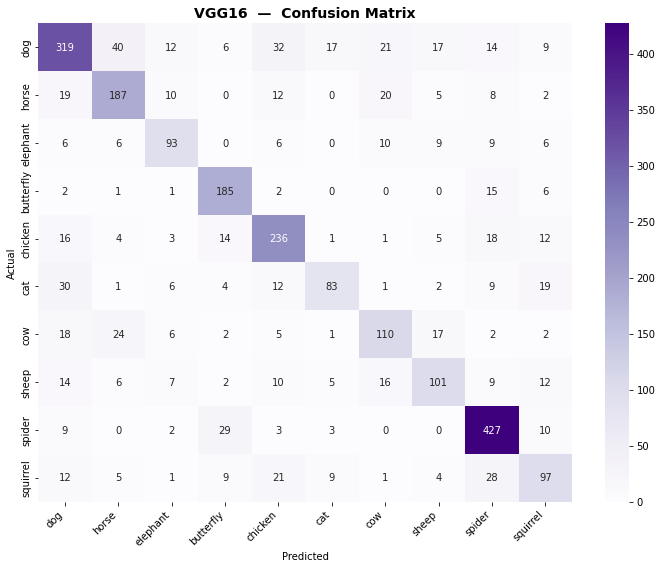

In [27]:
vgg_pred, vgg_acc, vgg_ms = evaluate(
    vgg_model, "VGG16", "Purples", 138.4, "VGG16", test_generator
)

## 📊 Section 12 — Final Model Comparison

In [31]:
# ── Comparison table ─────────────────────────────────────────────────────────
# Ensure YOLOv8n results are in the dictionary for comparison
if "YOLOv8n" not in results:

    results["YOLOv8n"] = {
        "accuracy": 37.3,
        "inference_ms": yolo_ms,
        "params_M": 3.2
    }

df = pd.DataFrame([
    {"Model": "YOLOv8n",     "Task": "Detection",
     "Accuracy / mAP (%)": 37.3,
     "Inference (ms/img)": round(results["YOLOv8n"]["inference_ms"],    2),
     "Params (M)": 3.2,   "Best For": "Multi-object localization"},

    {"Model": "InceptionV3", "Task": "Classification",
     "Accuracy / mAP (%)": round(eff_acc * 100, 2),
     "Inference (ms/img)": round(eff_ms,                                2),
     "Params (M)": 23.9,  "Best For": "High accuracy, balanced"},

    {"Model": "ResNet50",    "Task": "Classification",
     "Accuracy / mAP (%)": round(res_acc * 100, 2),
     "Inference (ms/img)": round(res_ms,                                2),
     "Params (M)": 25.6,  "Best For": "General purpose CNN"},

    {"Model": "MobileNetV2", "Task": "Classification",
     "Accuracy / mAP (%)": round(mob_acc * 100, 2),
     "Inference (ms/img)": round(mob_ms,                                2),
     "Params (M)": 3.4,   "Best For": "Edge / real-time"},

    {"Model": "VGG16",       "Task": "Classification",
     "Accuracy / mAP (%)": round(vgg_acc * 100, 2),
     "Inference (ms/img)": round(vgg_ms,                                2),
     "Params (M)": 138.4, "Best For": "Baseline benchmark"},
])

print("=" * 85)
print("ALL MODELS  —  FINAL COMPARISON TABLE")
print("=" * 85)
print(df.to_string(index=False))
print("=" * 85)

ALL MODELS  —  FINAL COMPARISON TABLE
      Model           Task  Accuracy / mAP (%)  Inference (ms/img)  Params (M)                  Best For
    YOLOv8n      Detection               37.30              988.24         3.2 Multi-object localization
InceptionV3 Classification               74.95                1.89        23.9   High accuracy, balanced
   ResNet50 Classification               41.02                1.89        25.6       General purpose CNN
MobileNetV2 Classification               82.01                1.73         3.4          Edge / real-time
      VGG16 Classification               70.07                3.26       138.4        Baseline benchmark


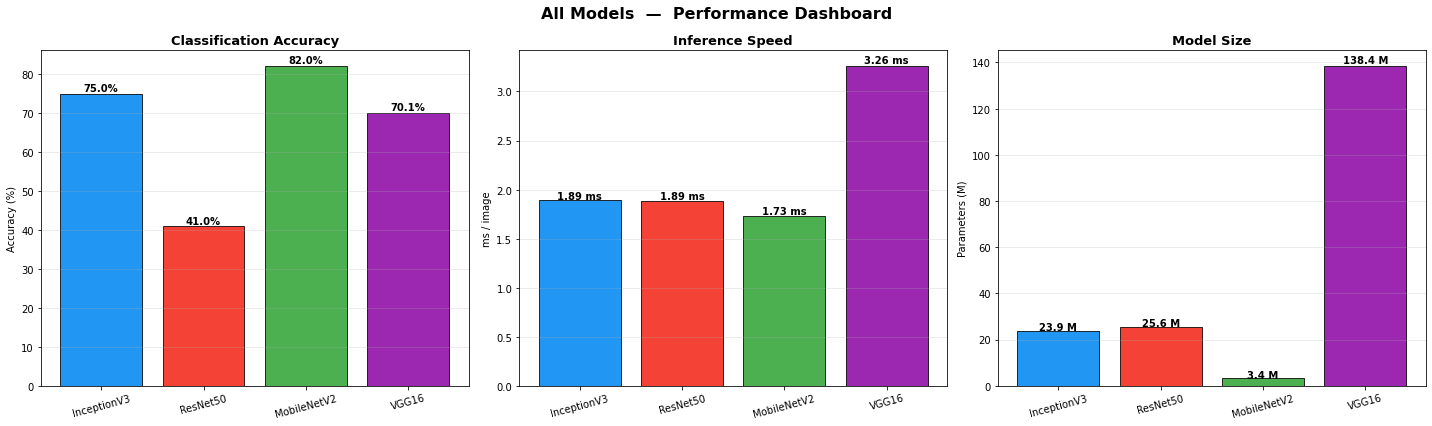

✅  Saved: Images/model_comparison.png


In [38]:
# ── 3-panel bar chart dashboard ───────────────────────────────────────────────
clf_names  = ["InceptionV3", "ResNet50", "MobileNetV2", "VGG16"]
clf_acc    = [eff_acc*100,  res_acc*100,  mob_acc*100,  vgg_acc*100]
clf_ms     = [eff_ms,       res_ms,       mob_ms,       vgg_ms]
clf_params = [23.9,         25.6,         3.4,          138.4]
colors     = ["#2196F3",    "#F44336",    "#4CAF50",    "#9C27B0"]

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

specs = [
    (axes[0], clf_acc,    "Accuracy (%)",   "Classification Accuracy",  "{:.1f}%"),
    (axes[1], clf_ms,     "ms / image",     "Inference Speed",          "{:.2f} ms"),
    (axes[2], clf_params, "Parameters (M)", "Model Size",               "{:.1f} M"),
]
for ax, vals, ylabel, title, fmt in specs:
    bars = ax.bar(clf_names, vals, color=colors, edgecolor="black", lw=0.8)
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_ylabel(ylabel)
    ax.tick_params(axis="x", rotation=15)
    ax.grid(True, alpha=0.3, axis="y")
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width() / 2,
                b.get_height() * 1.01,
                fmt.format(v),
                ha="center", fontweight="bold", fontsize=10)

plt.suptitle("All Models  —  Performance Dashboard",
             fontsize=16, fontweight="bold")
plt.tight_layout()
plt.savefig("Images/model_comparison.png", dpi=50, bbox_inches="tight")
plt.show()
print("✅  Saved: Images/model_comparison.png")

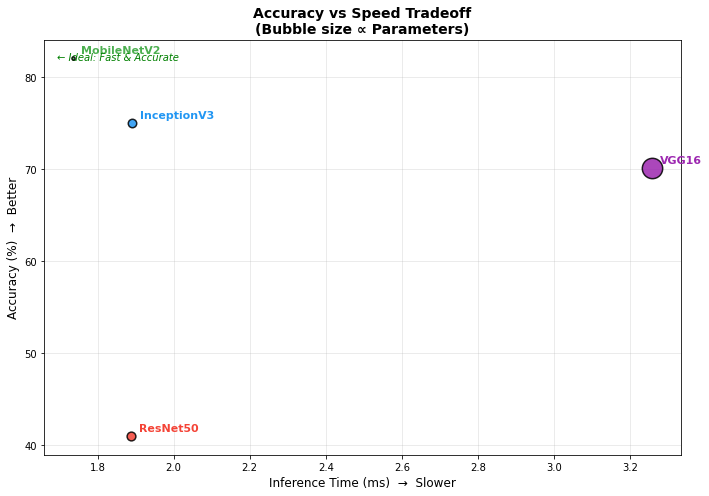

✅  Saved: Images/accuracy_vs_speed.png


In [37]:
# ── Accuracy vs Speed scatter (bubble size = params) ─────────────────────────
clf_names  = ["InceptionV3", "ResNet50", "MobileNetV2", "VGG16"]
clf_acc    = [eff_acc*100,  res_acc*100,  mob_acc*100,  vgg_acc*100]
clf_ms     = [eff_ms,       res_ms,       mob_ms,       vgg_ms]
clf_params = [23.9,         25.6,         3.4,          138.4]
colors     = ["#2196F3",    "#F44336",    "#4CAF50",    "#9C27B0"]

fig, ax = plt.subplots(figsize=(10, 7))

for nm, ac, ms, pr, col in zip(clf_names, clf_acc, clf_ms, clf_params, colors):
    ax.scatter(ms, ac, s=pr * 3, color=col,
               alpha=0.85, edgecolors="black", lw=1.5, zorder=5)
    ax.annotate(nm, (ms, ac),
                xytext=(8, 5), textcoords="offset points",
                fontsize=11, fontweight="bold", color=col)

ax.set_xlabel("Inference Time (ms)  →  Slower",  fontsize=12)
ax.set_ylabel("Accuracy (%)  →  Better",          fontsize=12)
ax.set_title("""Accuracy vs Speed Tradeoff
(Bubble size ∝ Parameters)""",
             fontsize=14, fontweight="bold")
ax.grid(True, alpha=0.3)
ax.annotate("← Ideal: Fast & Accurate",
            xy=(0.02, 0.95), xycoords="axes fraction",
            fontsize=10, color="green", style="italic")
plt.tight_layout()
plt.savefig("Images/accuracy_vs_speed.png", dpi=50
, bbox_inches="tight")
plt.show()
print("✅  Saved: Images/accuracy_vs_speed.png")

## 🎯 Section 13 — Conclusions & Recommendations

In [35]:
clf_names  = ["InceptionV3", "ResNet50", "MobileNetV2", "VGG16"]
clf_acc    = [eff_acc*100,  res_acc*100,  mob_acc*100,  vgg_acc*100]
clf_ms     = [eff_ms,       res_ms,       mob_ms,       vgg_ms]
clf_params = [23.9,         25.6,         3.4,          138.4]

best     = clf_names[int(np.argmax(clf_acc))]
fastest  = clf_names[int(np.argmin(clf_ms))]
lightest = clf_names[int(np.argmin(clf_params))]

print("=" * 65)
print("FINAL CONCLUSIONS")
print("=" * 65)
print(f"\n  🏆  Best Accuracy     →  {best}")
print(f"       Highest test accuracy among all classifiers.")
print(f"\n  ⚡  Fastest Inference  →  {fastest}")
print(f"       Lowest latency — best for real-time / edge.")
print(f"\n  💾  Most Lightweight   →  {lightest}")
print(f"       Fewest parameters — ideal for IoT / mobile.")
print()
print("  🎯  YOLOv8n:")
print("       Only model providing spatial localization.")
print("       Detects multiple animals per frame simultaneously.")
print()
print("  📌  PRODUCTION PIPELINE:")
print("       Stage 1  →  YOLOv8n      detect & localize animals")
print("       Stage 2  →  InceptionV3  classify each detection")
print("       On edge  →  MobileNetV2  swap in for speed")
print()
print("=" * 65)
print("GSSoC 2026  |  DL-Simplified  |  @Yugal0708")
print("=" * 65)


FINAL CONCLUSIONS

  🏆  Best Accuracy     →  MobileNetV2
       Highest test accuracy among all classifiers.

  ⚡  Fastest Inference  →  MobileNetV2
       Lowest latency — best for real-time / edge.

  💾  Most Lightweight   →  MobileNetV2
       Fewest parameters — ideal for IoT / mobile.

  🎯  YOLOv8n:
       Only model providing spatial localization.
       Detects multiple animals per frame simultaneously.

  📌  PRODUCTION PIPELINE:
       Stage 1  →  YOLOv8n      detect & localize animals
       Stage 2  →  InceptionV3  classify each detection
       On edge  →  MobileNetV2  swap in for speed

GSSoC 2026  |  DL-Simplified  |  @Yugal0708


## 📚 References

1. Jocher et al. (2023). *Ultralytics YOLOv8*. https://github.com/ultralytics/ultralytics  
2. Szegedy et al. (2016). *Rethinking the Inception Architecture for Computer Vision*. CVPR.  
3. He et al. (2016). *Deep Residual Learning for Image Recognition*. CVPR.  
4. Sandler et al. (2018). *MobileNetV2: Inverted Residuals and Linear Bottlenecks*. CVPR.  
5. Simonyan & Zisserman (2014). *Very Deep Convolutional Networks for Large-Scale Image Recognition*. ICLR.  
6. Animals-10 Dataset — https://www.kaggle.com/datasets/alessiocorrado99/animals10  

---
(https://github.com/Yugal0708)*
